<a href="https://colab.research.google.com/github/suyashjaiswal235-jpg/iMAPP-Applied-DL/blob/main/exercise_7_1_cifar_10_densenet_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# -*- coding: utf-8 -*-


Exercise 7.1 CIFAR-10: DenseNet solution.

This script is Colab-friendly and can be exported as a notebook/PDF after it is
run. It implements a small DenseNet for CIFAR-10 with:

- at least two dense blocks
- at least three densely connected convolutional layers per dense block
- training/validation accuracy plots
- final test accuracy output
- a confusion matrix


In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

layers = tf.keras.layers

tf.keras.utils.set_random_seed(42)
print("GPUs available:", tf.config.list_physical_devices("GPU"))


GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Helper functions


In [4]:
def plot_examples(X, Y, n=10):
    """Plot the first n examples for each of the 10 CIFAR-10 classes."""
    fig, axes = plt.subplots(n, 10, figsize=(10, n))
    for label in range(10):
        axes[0, label].set_title(cifar10_labels[label], fontsize="smaller")
        mask = np.squeeze(Y) == label
        for i in range(n):
            image = X[mask][i].astype("uint8")
            ax = axes[i, label]
            ax.imshow(image, origin="upper")
            ax.set(xticks=[], yticks=[])
    fig.tight_layout()
    return fig, axes


def plot_prediction(X, Y, Y_predict):
    """
    Plot image X along with predicted probabilities Y_predict.

    X: CIFAR image, shape = (32, 32, 3)
    Y: CIFAR label, one-hot encoded, shape = (10)
    Y_predict: predicted probabilities, shape = (10)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    ax1.imshow(X.astype("uint8"), origin="upper")
    ax1.set(xticks=[], yticks=[])

    ax2.barh(np.arange(10), Y_predict, align="center")
    ax2.set(xlim=(0, 1), xlabel="Score", yticks=[])
    for i in range(10):
        color = "red" if i == np.argmax(Y) else "black"
        ax2.text(
            0.05,
            i,
            cifar10_labels[i].capitalize(),
            ha="left",
            va="center",
            color=color,
        )
    fig.tight_layout()
    return fig, (ax1, ax2)


def plot_confusion(Y_true, Y_predict):
    """
    Plot a normalized confusion matrix with raw counts in each cell.

    Y_true: array of true classifications (0-9), shape = (N)
    Y_predict: array of predicted classifications (0-9), shape = (N)
    """
    counts = np.histogram2d(
        Y_true,
        Y_predict,
        bins=np.linspace(-0.5, 9.5, 11),
    )[0]
    normalized = counts / np.maximum(np.sum(counts, axis=1, keepdims=True), 1)

    fig, ax = plt.subplots(figsize=(8, 7))
    image = ax.imshow(
        normalized,
        interpolation="nearest",
        vmin=0,
        vmax=1,
        cmap=plt.cm.YlGnBu,
    )
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    ax.set(
        xlabel="prediction",
        ylabel="truth",
        xticks=range(10),
        yticks=range(10),
        xticklabels=cifar10_labels,
        yticklabels=cifar10_labels,
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    for true_class in range(10):
        for predicted_class in range(10):
            ax.annotate(
                "%i" % counts[true_class, predicted_class],
                xy=(predicted_class, true_class),
                ha="center",
                va="center",
                color="black",
                fontsize=8,
            )

    ax.set_title("DenseNet confusion matrix")
    fig.tight_layout()
    return fig, ax


def plot_training_history(history, title="DenseNet"):
    """Plot the standard training debug curves."""
    epochs = np.arange(1, len(history.history["accuracy"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history.history["accuracy"], label="Training accuracy")
    ax1.plot(epochs, history.history["val_accuracy"], label="Validation accuracy")
    ax1.set(xlabel="Epoch", ylabel="Accuracy", title=f"{title}: accuracy")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.plot(epochs, history.history["loss"], label="Training loss")
    ax2.plot(epochs, history.history["val_loss"], label="Validation loss")
    ax2.set(xlabel="Epoch", ylabel="Loss", title=f"{title}: loss")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    fig.tight_layout()
    return fig, (ax1, ax2)


## Load and preprocess CIFAR-10

The preprocessing is the same as in the previous exercise: labels are converted
to one-hot vectors, images are normalized to the range [0, 1], and 20% of the
original test split is used as validation data.


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4227s 25us/step
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Full test images shape: (10000, 32, 32, 3)


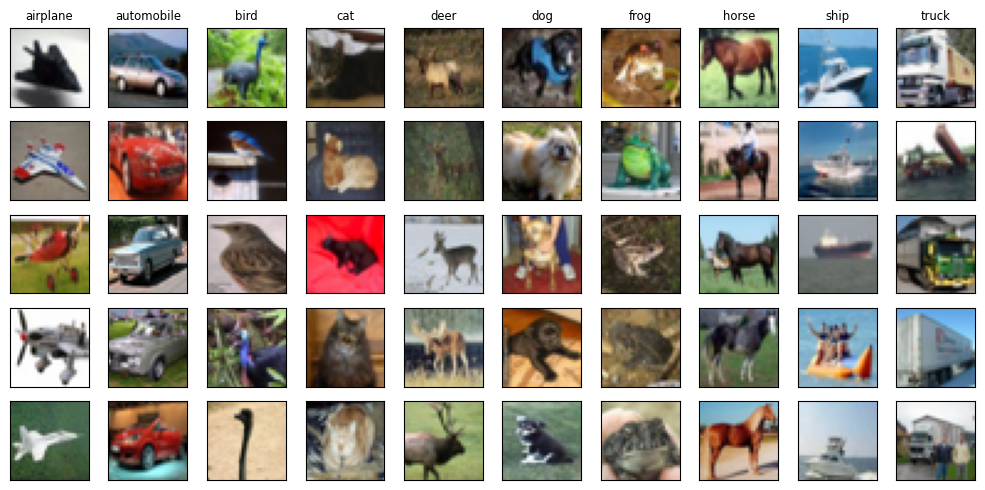

Training range: 0.0 1.0
Validation shape: (2000, 32, 32, 3)
Test shape: (8000, 32, 32, 3)


In [5]:
cifar10_labels = np.array(
    [
        "airplane",
        "automobile",
        "bird",
        "cat",
        "deer",
        "dog",
        "frog",
        "horse",
        "ship",
        "truck",
    ]
)

(x_train, y_train), (x_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Full test images shape:", x_test_full.shape)

plot_examples(x_train, y_train, n=5)
plt.show()

x_valid = x_test_full[8000:]
y_valid = y_test_full[8000:]
x_test = x_test_full[:8000]
y_test = y_test_full[:8000]

x_train_norm = x_train.astype("float32") / 255.0
x_valid_norm = x_valid.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_valid_onehot = tf.keras.utils.to_categorical(y_valid, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)

print("Training range:", x_train_norm.min(), x_train_norm.max())
print("Validation shape:", x_valid_norm.shape)
print("Test shape:", x_test_norm.shape)


## DenseNet model

DenseNet concatenates each convolutional layer's newly learned feature maps with
all previous feature maps inside the same dense block. This encourages feature
reuse and improves gradient flow compared with a plain stack of convolutions.

This implementation uses two dense blocks, and each block contains three
densely connected convolutional layers. That satisfies the requested minimum,
while keeping training time reasonable in Colab.


In [6]:
def dense_conv_layer(x, growth_rate, dropout_rate=0.15, name=None):
    """One DenseNet layer: BN -> ReLU -> 3x3 Conv -> Dropout -> Concatenate."""
    shortcut = x

    x = layers.BatchNormalization(name=None if name is None else f"{name}_bn")(x)
    x = layers.Activation("relu", name=None if name is None else f"{name}_relu")(x)
    x = layers.Conv2D(
        growth_rate,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=None if name is None else f"{name}_conv",
    )(x)
    if dropout_rate > 0:
        x = layers.Dropout(
            dropout_rate,
            name=None if name is None else f"{name}_dropout",
        )(x)

    return layers.Concatenate(name=None if name is None else f"{name}_concat")(
        [shortcut, x]
    )


def dense_block(x, num_layers, growth_rate, dropout_rate=0.15, name="dense_block"):
    """A dense block with repeated densely connected convolutional layers."""
    for layer_index in range(num_layers):
        x = dense_conv_layer(
            x,
            growth_rate=growth_rate,
            dropout_rate=dropout_rate,
            name=f"{name}_layer_{layer_index + 1}",
        )
    return x


def transition_layer(x, compression=0.5, dropout_rate=0.15, name="transition"):
    """Reduce feature maps and downsample between dense blocks."""
    filters = int(tf.keras.backend.int_shape(x)[-1] * compression)

    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    x = layers.Activation("relu", name=f"{name}_relu")(x)
    x = layers.Conv2D(
        filters,
        kernel_size=1,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv",
    )(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate, name=f"{name}_dropout")(x)
    x = layers.AveragePooling2D(pool_size=2, strides=2, name=f"{name}_avg_pool")(x)
    return x


def build_densenet(
    input_shape=(32, 32, 3),
    num_classes=10,
    growth_rate=8,
    block_layers=(3, 3),
    compression=0.5,
    dropout_rate=0.10,
):
    """Build a compact DenseNet suitable for CIFAR-10."""
    inputs = tf.keras.Input(shape=input_shape, name="image")

    data_augmentation = tf.keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
        ],
        name="data_augmentation",
    )

    x = data_augmentation(inputs)
    x = layers.Conv2D(
        16,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name="stem_conv",
    )(x)

    for block_index, num_layers in enumerate(block_layers):
        x = dense_block(
            x,
            num_layers=num_layers,
            growth_rate=growth_rate,
            dropout_rate=dropout_rate,
            name=f"dense_block_{block_index + 1}",
        )
        if block_index < len(block_layers) - 1:
            x = transition_layer(
                x,
                compression=compression,
                dropout_rate=dropout_rate,
                name=f"transition_{block_index + 1}",
            )

    x = layers.BatchNormalization(name="final_bn")(x)
    x = layers.Activation("relu", name="final_relu")(x)
    x = layers.GlobalAveragePooling2D(name="global_average_pool")(x)
    x = layers.Dropout(0.30, name="classifier_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="class_probs")(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name="densenet_cifar10")


model = build_densenet()
model.summary()

dummy_batch = tf.zeros((2, 32, 32, 3))
dummy_predictions = model(dummy_batch, training=False)
print("Sanity check prediction shape:", dummy_predictions.shape)
assert dummy_predictions.shape == (2, 10)
assert np.allclose(np.sum(dummy_predictions.numpy(), axis=1), 1.0, atol=1e-5)


Model: "densenet_cifar10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 3) │          0 │ image[0][0]       │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │        432 │ data_augmentatio… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_block_1_laye… │ (None, 32, 32,    │         64 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_block_1_laye… │ (None, 32, 32,    │          0 │ dense_block_1_la… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_block_1_laye… │ (None, 32, 32, 8) │      1,152 │ dense_block_1_la… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_block_1_laye… │ (None, 32, 32, 8) │          0 │ dense_block_1_la… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_block_1_laye… │ (None, 32, 32,    │          0 │ stem_conv[0][0],  │
│ (Concatenate)       │ 24)               │            │ dense_block_1_la… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_block_1_laye… │ (None, 32, 32,    │         96 │ dense_block_1_la… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_block_1_laye… │ (None, 32, 32,    │          0 │ dense_block_1_la… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_block_1_laye… │ (None, 32, 32, 8) │      1,728 │ dense_block_1_la… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_block_1_laye… │ (None, 32, 32, 8) │          0 │ dense_block_1_la… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_block_1_laye… │ (None, 32, 32,    │          0 │ dense_block_1_la… │
│ (Concatenate)       │ 32)               │            │ dense_block_1_la… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_block_1_laye… │ (None, 32, 32,    │        128 │ dense_block_1_la… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_block_1_laye… │ (None, 32, 32,    │          0 │ dense_block_1_la… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_block_1_laye… │ (None, 32, 32, 8) │      2,304 │ dense_block_1_la… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_block_1_laye… │ (None, 32, 32, 8) │          0 │ dense_block_1_la… │
│ (Dropout)           │                   │            │                 

 Total params: 13,874 (54.20 KB)

 Trainable params: 13,394 (52.32 KB)

 Non-trainable params: 480 (1.88 KB)

Sanity check prediction shape: (2, 10)


In [7]:
initial_learning_rate = 1e-3
batch_size = 256
epochs = 50

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=initial_learning_rate),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-5,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(f"history_{model.name}.csv"),
]

history = model.fit(
    x_train_norm,
    y_train_onehot,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(x_valid_norm, y_valid_onehot),
    callbacks=callbacks,
)


Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 35s 96ms/step - accuracy: 0.2545 - loss: 2.0100 - val_accuracy: 0.1680 - val_loss: 2.7055 - learning_rate: 0.0010
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.3561 - loss: 1.7003 - val_accuracy: 0.3240 - val_loss: 1.8344 - learning_rate: 0.0010
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4044 - loss: 1.5793 - val_accuracy: 0.3355 - val_loss: 1.9080 - learning_rate: 0.0010
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.4386 - loss: 1.4980 - val_accuracy: 0.4140 - val_loss: 1.6296 - learning_rate: 0.0010
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4604 - loss: 1.4489 - val_accuracy: 0.4115 - val_loss: 1.5463 - learning_rate: 0.0010
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4793 - loss: 1.4075 - val_accuracy: 0.4000 - val_loss: 1.5804 - learning_rate: 0.0010
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.4891 - loss: 1

## Evaluation and plots


Train Accuracy:      0.6553
Validation Accuracy: 0.6385
Test Accuracy:       0.6451
Test Loss:           0.9727


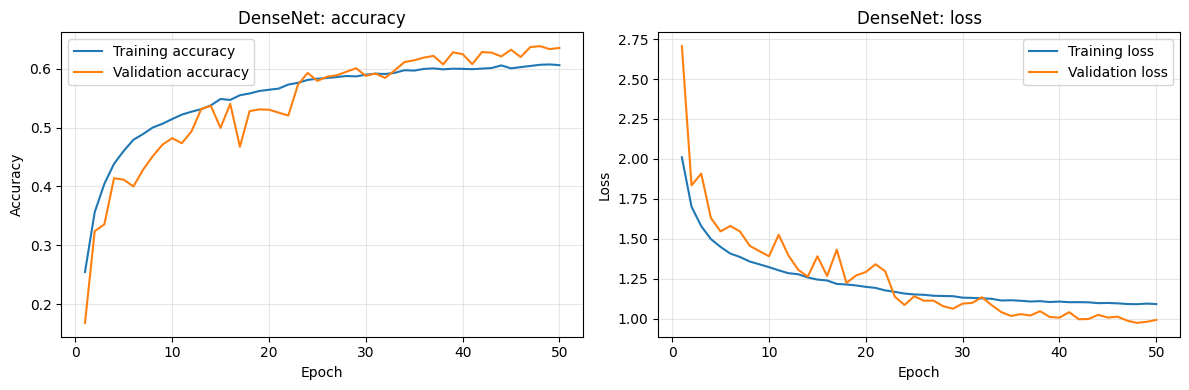

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step


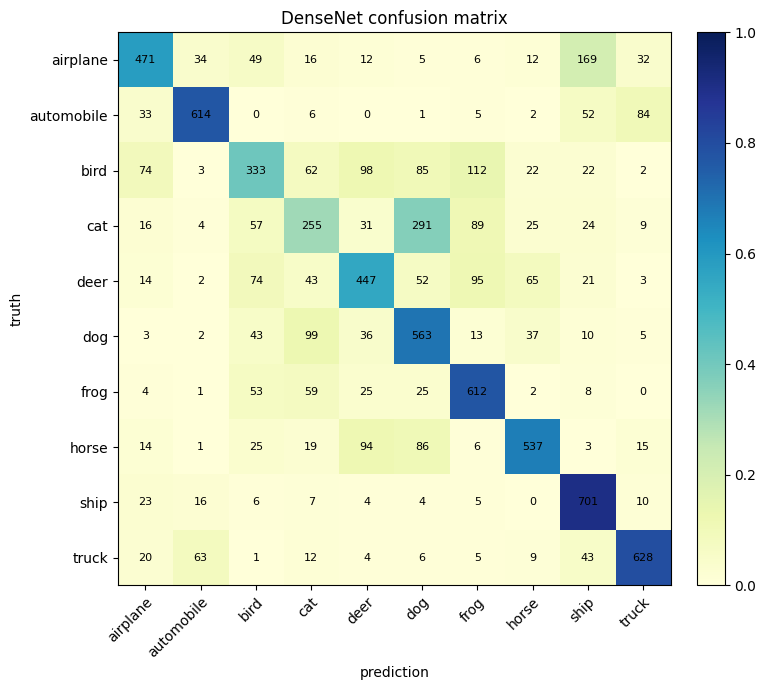

In [8]:
train_loss, train_acc = model.evaluate(x_train_norm, y_train_onehot, verbose=0)
valid_loss, valid_acc = model.evaluate(x_valid_norm, y_valid_onehot, verbose=0)
test_loss, test_acc = model.evaluate(x_test_norm, y_test_onehot, verbose=0)

print(f"Train Accuracy:      {train_acc:.4f}")
print(f"Validation Accuracy: {valid_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")
print(f"Test Loss:           {test_loss:.4f}")

plot_training_history(history, title="DenseNet")
plt.show()

y_predict = model.predict(x_test_norm, batch_size=batch_size)
y_predict_cl = np.argmax(y_predict, axis=1)
y_test_cl = np.squeeze(y_test)

plot_confusion(y_test_cl, y_predict_cl)
plt.show()


## Correct and incorrect predictions


Number of correct test predictions: 5161
Number of incorrect test predictions: 2839


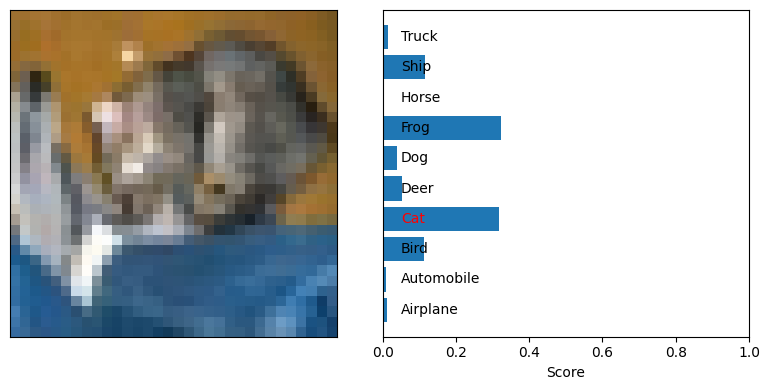

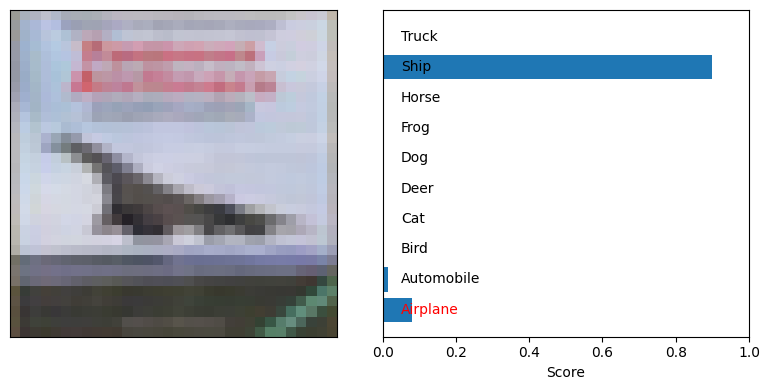

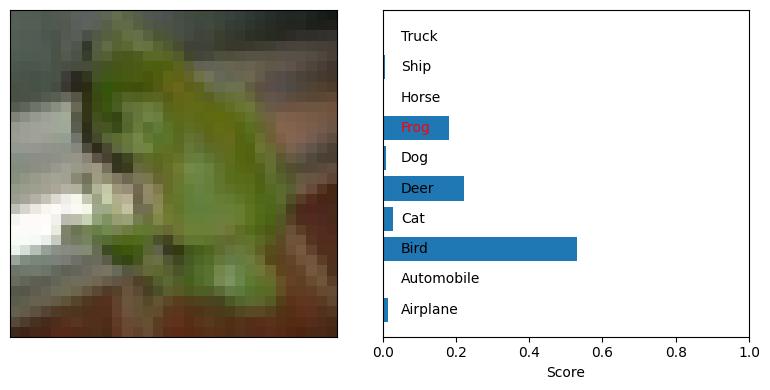

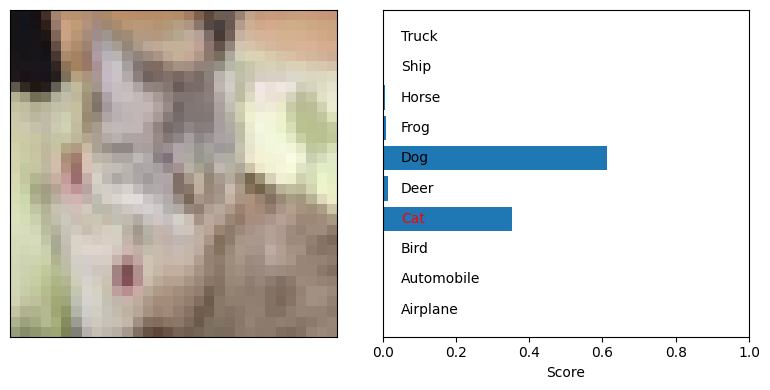

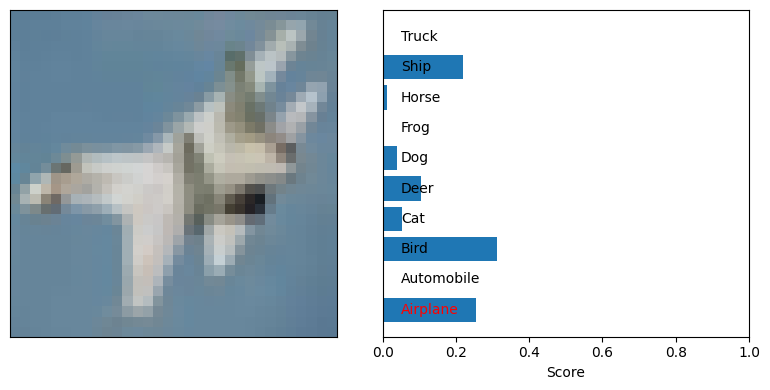

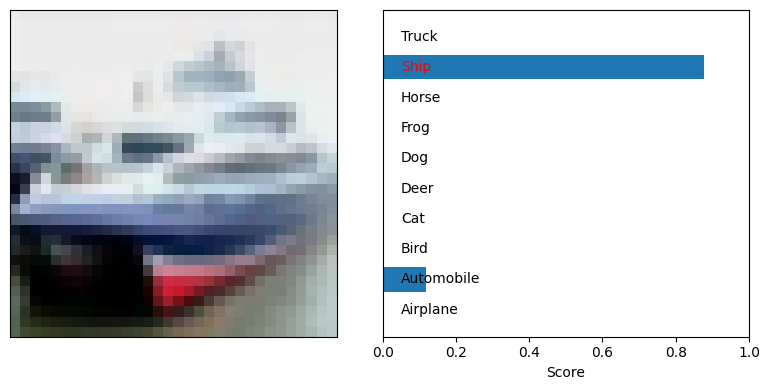

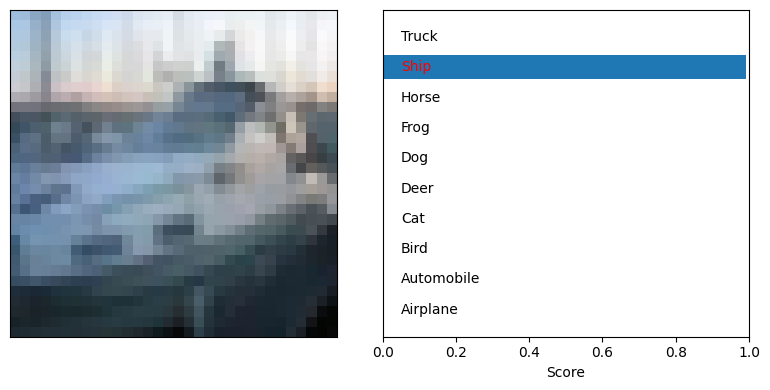

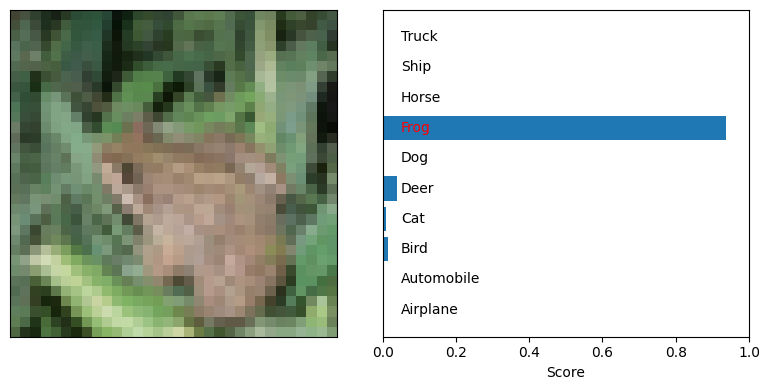

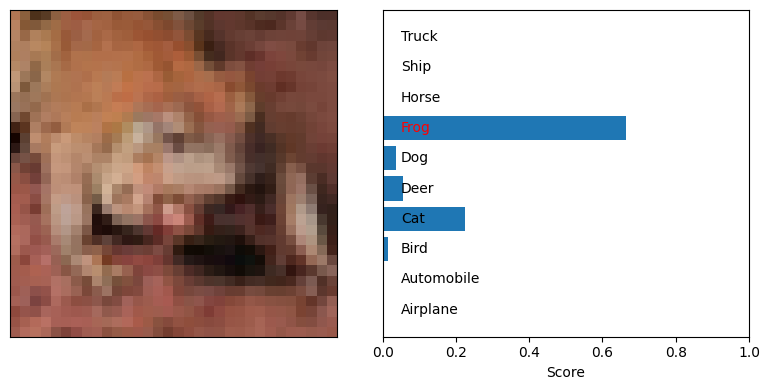

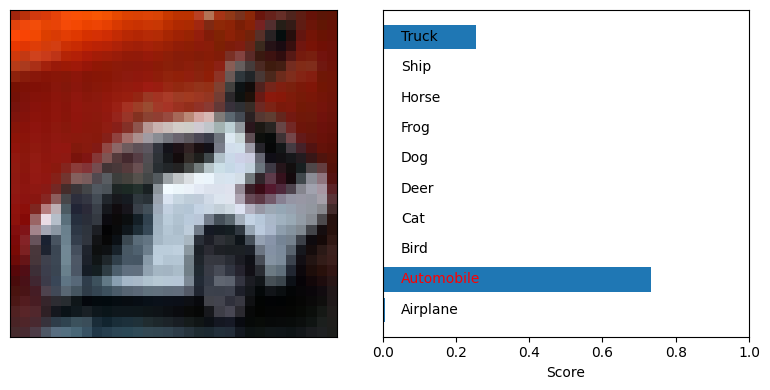

In [9]:
correct_mask = y_predict_cl == y_test_cl
incorrect_indices = np.arange(len(y_test_cl))[~correct_mask]
correct_indices = np.arange(len(y_test_cl))[correct_mask]

print("Number of correct test predictions:", len(correct_indices))
print("Number of incorrect test predictions:", len(incorrect_indices))

for i in incorrect_indices[:5]:
    plot_prediction(x_test[i], y_test_onehot[i], y_predict[i])
    plt.show()

for i in correct_indices[:5]:
    plot_prediction(x_test[i], y_test_onehot[i], y_predict[i])
    plt.show()


## Brief result comment

After running the notebook, replace the bracketed value below with the printed
test accuracy before exporting the PDF.

The DenseNet reached a final test accuracy of 64.51%.
The densely connected blocks reuse earlier features by concatenating each new
convolutional output with all previous outputs in the block. This helps the
network train deeper than a plain CNN with similar-sized layers. The training
curves should be checked for overfitting: a large gap between training and
validation accuracy means the model is fitting the training set too strongly.
The confusion matrix usually shows the hardest classes are visually similar
ones such as cat/dog, deer/horse, or automobile/truck.
